# Oplit Technical Interview — Workshop & Production Times

**The context.** Oplit helps factories **schedule their production**. A new client (a machining / welding / assembly workshop) wants help planning its operations. We'll start from *their* problem, not from the code.

## Part A — Workshop scheduling (flow shop)

The workshop makes 3 part types (A, B, C) on **2 machines**. Each part goes through Machine 1 **then** Machine 2 (in that order). A machine processes only one part at a time. The table below provides the processing times for each operation.

| Part | Machine 1 | Machine 2 |
|------|-----------|-----------|
| A    | 2 h       | 3 h       |
| B    | 4 h       | 1 h       |
| C    | 3 h       | 2 h       |

The workshop manager says: *“I want to get everything out as fast as possible.”*

💬 **To discuss (no mathematical model expected):**
- What are we trying to optimize, in the client's words and then in yours?
- What do we actually **decide** here? Which **constraints** can't be violated?
- What **simple rule** (heuristic) could a human planner apply? Why would it be reasonable?

## Part B — Predicting processing times

Problem: everything we just did assumes we **know** the duration of each operation (2 h, 4 h…). In the real world, the same operation takes a different time depending on the part, the machine, the batch size, and even the state of the factory at time t.

The client has no standard times of their own — they have a **raw export of what actually happened** on the workshop floor. So the scheduling problem silently depends on a **prediction** problem: *how long will this operation take?*

⚠️ Catch: the **actual duration is not a column in the file**. The export only has **timestamps** (actual start / end). You have to reconstruct the target.

Here is a sample of the client export. **React to what you see.**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Works locally (cloned repo) AND on Google Colab (auto-download from GitHub)
LOCAL_PATH = "../data/operations_raw.csv"
RAW_URL = "https://raw.githubusercontent.com/alexandrerioo/scheduling_sandbox/main/data/operations_raw.csv"
CSV = LOCAL_PATH if os.path.exists(LOCAL_PATH) else RAW_URL

df = pd.read_csv(CSV, dtype=str)
print(f"{len(df):,} rows  x  {df.shape[1]} columns")
df.head(10)

6,090 rows  x  14 columns


,of_id,article_ref,article_family,diameter_mm,material,color,quantity,machine_id,machine_type,actual_start_ts,actual_end_ts,downtime_min,status,record_created_ts
0,OF-2024-00000,ART-F11,Finition,147.9,Acier,Gris,66,MCH-07,MANUAL,10/05/2024 21:18,10/05/2024 23:02,0.0,done,10/05/2024 23:06
1,OF-2024-00001,ART-A26,Assemblage,183.1,Inox,Rouge,63,MCH-10,ROBOT_CELL,2024-04-26 13:16:55,NaN,8.9,running,2024-04-26 15:03:26
2,OF-2024-00002,ART-F07,Finition,147.0,Acier,Gris,28,MCH-01,CNC_FAST,2024-07-26 08:24:11,2024-07-26 08:45:21,0.0,done,2024-07-26 08:49:06
3,OF-2024-00003,ART-U24,Usinage,173.0,Aluminium,Vert,193,MCH-02,CNC_FAST,2024-07-07 18:16:47,2024-07-07 22:16:33,48.0,done,2024-07-07 22:19:52
4,OF-2024-00004,ART-S25,Soudure,151.9,Acier,Bleu,67,MCH-07,MANUAL,08/04/2024 09:08,08/04/2024 15:39,58.1,done,08/04/2024 15:42
5,OF-2024-00005,ART-U28,Usinage,115.2,Aluminium,Bleu,36,MCH-04,CNC_STD,2024-06-29 08:18:03,2024-06-29 09:31:43,0.0,done,2024-06-29 09:34:31
6,OF-2024-00006,ART-U00,Usinage,184.0,Inox,Jaune,54,MCH-03,CNC_STD,2024-04-28 21:55:41,2024-04-29 00:26:00,0.0,done,2024-04-29 00:26:57
7,OF-2024-00007,ART-A26,Assemblage,183.1,Inox,Rouge,65,MCH-11,ROBOT_CELL,2024-07-24 20:06:41,2024-07-24 22:03:36,0.0,done,2024-07-24 22:06:57
8,OF-2024-00008,ART-U32,Usinage,131.7,Aluminium,Gris,64,MCH-05,CNC_STD,2024-01-22 21:28:13,2024-01-23 00:45:53,53.5,done,2024-01-23 00:49:19
9,OF-2024-00009,ART-F19,Finition,100.8,Aluminium,Gris,34,MCH-08,MANUAL,2024-04-10 07:02:55,2024-04-10 07:50:57,0.0,done,2024-04-10 07:52:38


### Column glossary

| Column | Description |
|---|---|
| `of_id` | Manufacturing Order (work order) |
| `article_ref`, `article_family` | Article reference and family (Machining, Welding, Assembly, Finishing) |
| `diameter_mm` | Part diameter (mm) |
| `material` | Material: Aluminium / Steel / Stainless / Titanium |
| `color` | Part color |
| `quantity` | Operation quantity |
| `machine_id`, `machine_type` | Physical machine and its type |
| `actual_start_ts`, `actual_end_ts` | Actual start / end of the operation |
| `downtime_min` | Minutes the machine was stopped during the operation |
| `status` | done / running / aborted |
| `record_created_ts` | Timestamp the row was written by the MES |

In [2]:
# Volume & period
# NB: date formats are not homogeneous across sources -> we parse both
iso = pd.to_datetime(df["actual_start_ts"], format="%Y-%m-%d %H:%M:%S", errors="coerce")
fr  = pd.to_datetime(df["actual_start_ts"], format="%d/%m/%Y %H:%M", errors="coerce")
ts = iso.fillna(fr)
print("Period:", ts.min(), "->", ts.max())
print("Distinct work orders  :", df["of_id"].nunique())
print("Article references     :", df["article_ref"].nunique(), "(surface forms)")
print("Materials / colors     :", df["material"].nunique(), "/", df["color"].nunique())
print("Machines / types       :", df["machine_id"].nunique(), "/", df["machine_type"].nunique())
print("actual_end_ts missing  :", (df["actual_end_ts"].fillna('') == '').sum(), "rows")
print("Duplicated rows        :", df.duplicated().sum())

Period: 2024-01-01 06:06:00 -> 2024-08-31 22:08:35
Distinct work orders  : 6000
Article references     : 89 (surface forms)
Materials / colors     : 4 / 6
Machines / types       : 12 / 4
actual_end_ts missing  : 244 rows
Duplicated rows        : 62


### 📊 Three visualizations to kick off the discussion

#### 1. Observations per article

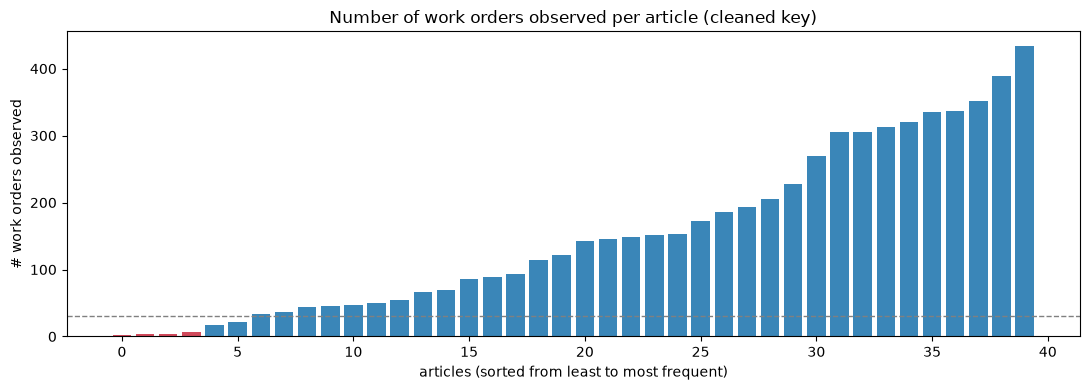

Distinct articles (cleaned): 40
Lowest volumes             : [np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(17), np.int64(21)]


In [3]:
import matplotlib.pyplot as plt

# "canonical" article key: clean up whitespace / case / dash / junk suffix
canon = (df["article_ref"].str.strip().str.upper()
         .str.replace("-", "", regex=False).str.replace("MM", "", regex=False))
counts = canon.value_counts().sort_values()

plt.figure(figsize=(11, 4))
colors = ["#d1495b" if v <= 8 else "#3a86b8" for v in counts.values]
plt.bar(range(len(counts)), counts.values, color=colors)
plt.axhline(30, ls="--", lw=1, color="grey")
plt.title("Number of work orders observed per article (cleaned key)")
plt.xlabel("articles (sorted from least to most frequent)")
plt.ylabel("# work orders observed")
plt.tight_layout(); plt.show()

print("Distinct articles (cleaned):", counts.size)
print("Lowest volumes             :", sorted(counts.values)[:6])

#### 2. Target distribution

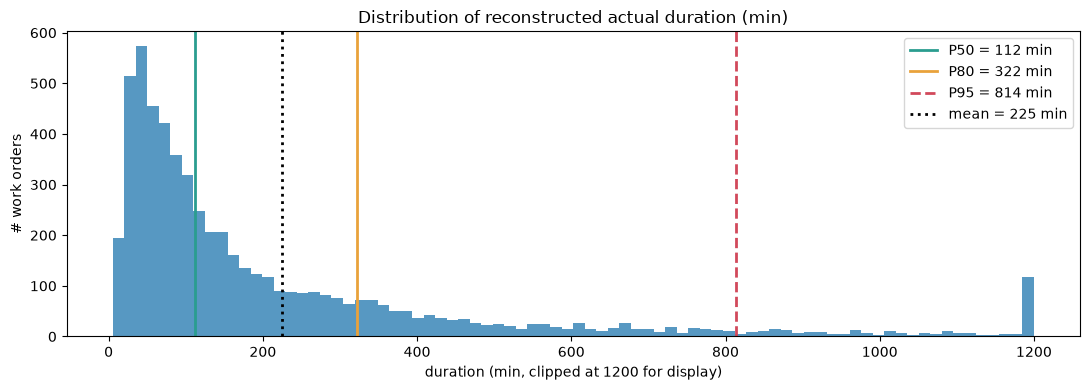

median=112 | mean=225 | P80=322 | P95=814  (min)


In [4]:
import numpy as np

def parse_ts(s):
    a = pd.to_datetime(s, format="%Y-%m-%d %H:%M:%S", errors="coerce")
    b = pd.to_datetime(s, format="%d/%m/%Y %H:%M", errors="coerce")
    return a.fillna(b)

# reconstructed target = end - start, in minutes (drop durations <= 0 and missing)
dur = (parse_ts(df["actual_end_ts"]) - parse_ts(df["actual_start_ts"])).dt.total_seconds() / 60
dur = dur[dur > 0]

plt.figure(figsize=(11, 4))
plt.hist(dur.clip(upper=1200), bins=80, color="#3a86b8", alpha=.85)
for p, c, ls in [(50, "#2a9d8f", "-"), (80, "#e9a23b", "-"), (95, "#d1495b", "--")]:
    v = np.percentile(dur, p)
    plt.axvline(v, color=c, ls=ls, lw=2, label=f"P{p} = {v:.0f} min")
plt.axvline(dur.mean(), color="black", ls=":", lw=2, label=f"mean = {dur.mean():.0f} min")
plt.title("Distribution of reconstructed actual duration (min)")
plt.xlabel("duration (min, clipped at 1200 for display)")
plt.ylabel("# work orders")
plt.legend(); plt.tight_layout(); plt.show()

print(f"median={dur.median():.0f} | mean={dur.mean():.0f} | "
      f"P80={np.percentile(dur,80):.0f} | P95={np.percentile(dur,95):.0f}  (min)")

#### 3. Is `downtime_min`: a good feature?

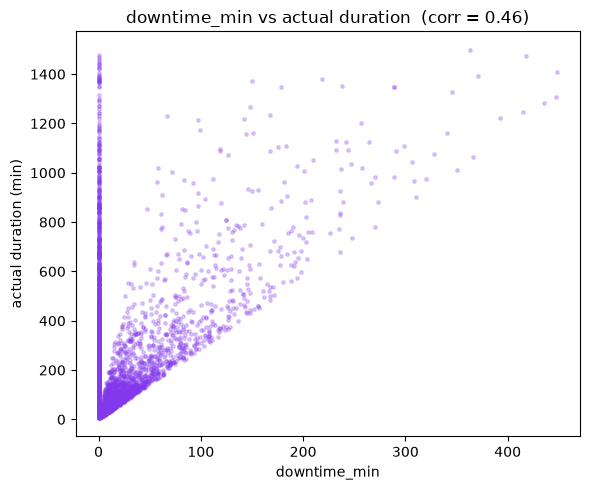

In [5]:
dt = pd.to_numeric(df["downtime_min"], errors="coerce")
dur_all = (parse_ts(df["actual_end_ts"]) - parse_ts(df["actual_start_ts"])).dt.total_seconds() / 60
m = dur_all.between(0.1, 1500) & dt.notna()

plt.figure(figsize=(6, 5))
plt.scatter(dt[m], dur_all[m], s=6, alpha=.25, color="#8338ec")
plt.title(f"downtime_min vs actual duration  (corr = {dt[m].corr(dur_all[m]):.2f})")
plt.xlabel("downtime_min")
plt.ylabel("actual duration (min)")
plt.tight_layout(); plt.show()

In [6]:
# Free workspace
